In [1]:
#imports and settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report,roc_curve)
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

plt.style.use("default")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)

In [2]:
#loading the dataset
df = pd.read_csv("CreditScore.csv")
print("Dataset shape:", df.shape)
df

Dataset shape: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


SeriousDlqin2yrs is our target variable to predict. 

<br>
<h1><center><b>Exploratory Data Analysis</b></center></h1>

In [3]:
df.head(10) #print first 10 rows of dataset

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
5,6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
6,7,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
7,8,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
8,9,0,0.116951,27,0,46.000000,NaN,2,0,0,0,NaN
9,10,0,0.189169,57,0,0.606291,23684.0,9,0,4,0,2.0


In [4]:
df.tail(10) #print last 10 rows of dataset

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
149990,149991,0,0.055518,46,0,0.609779,4335.0,7,0,1,0,2.0
149991,149992,0,0.104112,59,0,0.477658,10316.0,10,0,2,0,0.0
149992,149993,0,0.871976,50,0,4132.000000,NaN,11,0,1,0,3.0
149993,149994,0,1.000000,22,0,0.000000,820.0,1,0,0,0,0.0
149994,149995,0,0.385742,50,0,0.404293,3400.0,7,0,0,0,0.0
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0
149999,150000,0,0.850283,64,0,0.249908,8158.0,8,0,2,0,0.0


<br>
<h3><b>Basic Inspection</b></h3>

In [5]:
#priniting all dataset columns/features names
print(df.columns.tolist())

['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


In [6]:
# checking datatypes and non null counts 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

So, MonthlyIncome and NumberOfDependents have missing values 

In [7]:
# checking mean, std, min, max etc
print("Dataset summary statistics:")
display(df.describe())

Dataset summary statistics:


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [8]:
# checking Unique values per column
df.nunique().to_frame("Unique")

,Unique
Unnamed: 0,150000
SeriousDlqin2yrs,2
RevolvingUtilizationOfUnsecuredLines,125728
age,86
NumberOfTime30-59DaysPastDueNotWorse,16
DebtRatio,114194
MonthlyIncome,13594
NumberOfOpenCreditLinesAndLoans,58
NumberOfTimes90DaysLate,19
NumberRealEstateLoansOrLines,28


ther is an unnamed:0 column which looks like an index. Not a predictive feature so will drop it, so it won't effect duplicate count

In [9]:
new_df = df.copy()

In [10]:
new_df = new_df.drop(columns=["Unnamed: 0"])

In [11]:
new_df.shape

(150000, 11)

<br>
<h3><b>Data quality check</b></h3>

In [12]:
#checking missing values per column
print("Missing values in dataset")
missing = new_df.isna().sum().to_frame("Missing-Count")
missing["Missing-Percent"]=(missing["Missing-Count"]/len(new_df))*100
display(missing)
print("Total missing values:",new_df.isnull().sum().sum()) 

Missing values in dataset


,Missing-Count,Missing-Percent
SeriousDlqin2yrs,0,0.000000
RevolvingUtilizationOfUnsecuredLines,0,0.000000
age,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
DebtRatio,0,0.000000
MonthlyIncome,29731,19.820667
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000
NumberRealEstateLoansOrLines,0,0.000000
NumberOfTime60-89DaysPastDueNotWorse,0,0.000000


Total missing values: 33655


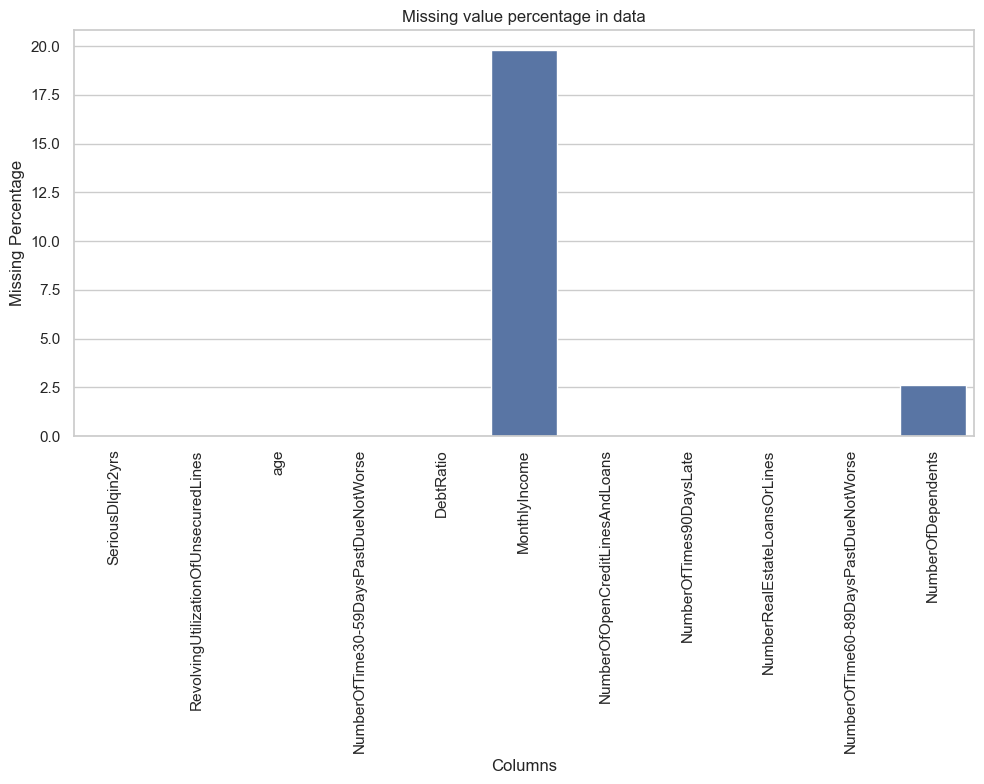

In [13]:
#visualizing te missing values in dataset
plt.figure(figsize=(10,8))
sns.barplot(x=missing.index,y=missing["Missing-Percent"])
plt.xticks(rotation=90)
plt.title("Missing value percentage in data")
plt.ylabel("Missing Percentage")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()

In [14]:
# checking for duplicate rows
print("Duplicate rows in data:", new_df.duplicated().sum())

Duplicate rows in data: 609


So, data contains 609 duplicate rows (excluding unnamed:0)

<br>
<h3><b>Target Variable Analysis</b></h3>

In [15]:
target_counts = new_df["SeriousDlqin2yrs"].value_counts()
display(target_counts.to_frame("Count"))

,Count
SeriousDlqin2yrs,
0,139974
1,10026


Clearly, there is a high class imbalance

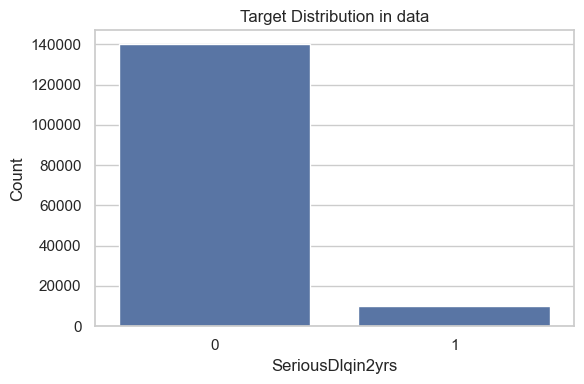

In [16]:
# countplot for visualizing target distribution
plt.figure(figsize=(6,4))
sns.countplot(x="SeriousDlqin2yrs",data=new_df)
plt.title("Target Distribution in data")
plt.xlabel("SeriousDlqin2yrs")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [17]:
# target distribution in percentage
target_percent = display((new_df["SeriousDlqin2yrs"].value_counts(normalize=True)*100).round(2).to_frame("Percent"))

,Percent
SeriousDlqin2yrs,
0,93.32
1,6.68


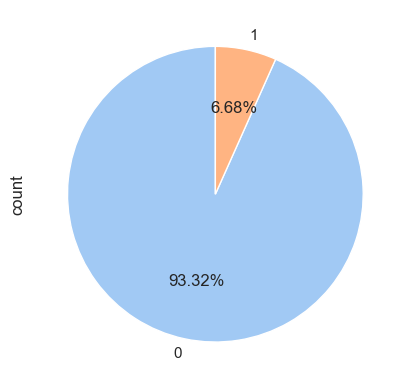

In [18]:
# plotting pie chart to visulize percentage 
color = sns.color_palette('pastel')
new_df['SeriousDlqin2yrs'].value_counts().plot(kind='pie',autopct='%1.2f%%',startangle=90,colors=color)
plt.show()

<br>
<h3><b>FEATURE TYPE SPLIT</b></h3>

In [19]:
feature_cols = [col for col in new_df.columns if col!="SeriousDlqin2yrs"]

In [20]:
continuous_cols=["RevolvingUtilizationOfUnsecuredLines","age","DebtRatio","MonthlyIncome","NumberOfOpenCreditLinesAndLoans",
                   "NumberRealEstateLoansOrLines","NumberOfDependents"]
delinquency_cols=["NumberOfTime30-59DaysPastDueNotWorse","NumberOfTimes90DaysLate","NumberOfTime60-89DaysPastDueNotWorse"]
print("Continuous columns:",continuous_cols)
print("Delinquency columns:",delinquency_cols)

Continuous columns: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']
Delinquency columns: ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime60-89DaysPastDueNotWorse']


In [21]:
# priniting summary statistics
display(new_df[continuous_cols+delinquency_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfDependents,146076.0,0.757222,1.115086,0.0,0.000000,0.000000,1.000000,20.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [22]:
#checking for skewnwess
display(new_df[continuous_cols+delinquency_cols].skew().to_frame("Skewness"))

,Skewness
RevolvingUtilizationOfUnsecuredLines,97.631574
age,0.188995
DebtRatio,95.157793
MonthlyIncome,114.040318
NumberOfOpenCreditLinesAndLoans,1.215314
NumberRealEstateLoansOrLines,3.482484
NumberOfDependents,1.588242
NumberOfTime30-59DaysPastDueNotWorse,22.597108
NumberOfTimes90DaysLate,23.087345
NumberOfTime60-89DaysPastDueNotWorse,23.331743


Many features show high positive skewness (e.g., RevolvingUtilizationOfUnsecuredLines, MonthlyIncome and DebtRatio), so we will later evaluate for potential outliers

<br>
<h3><b>NUMERICAL FEATURE ANALYSIS</b></h3>

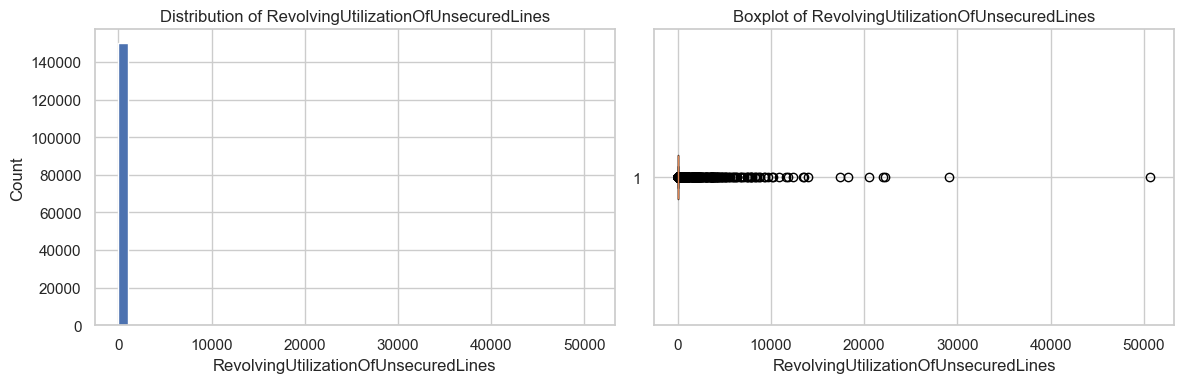

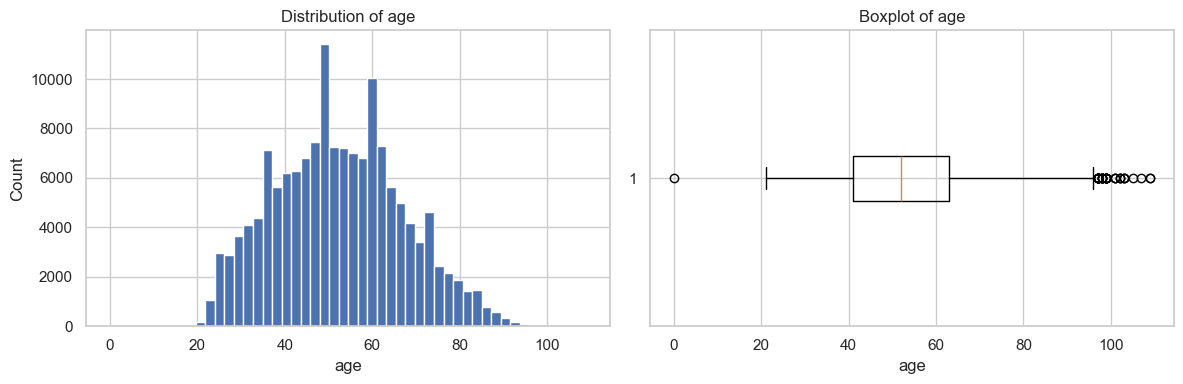

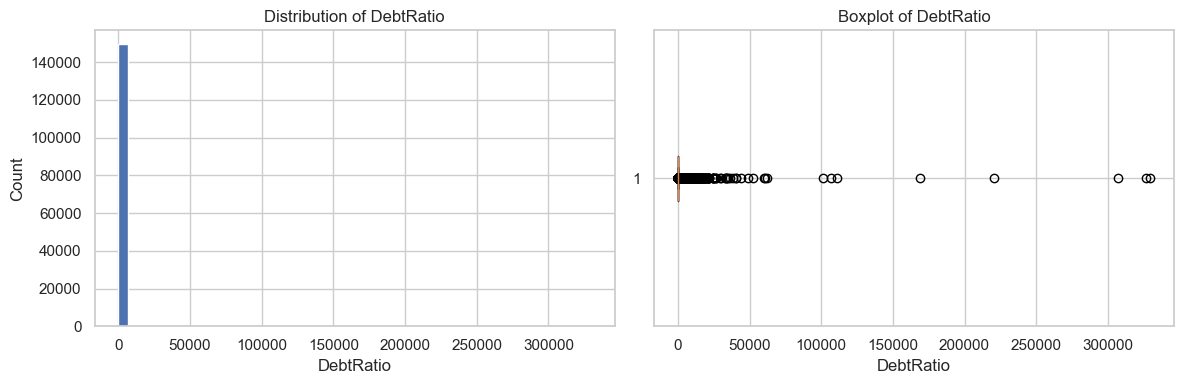

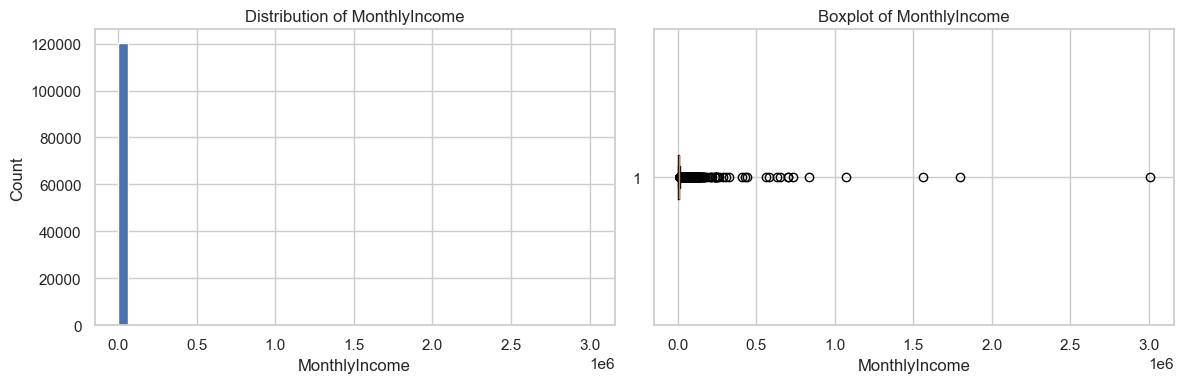

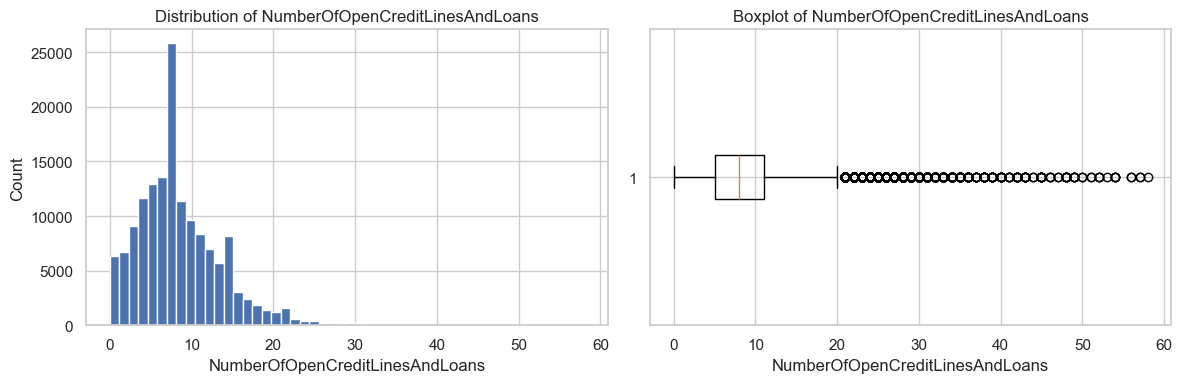

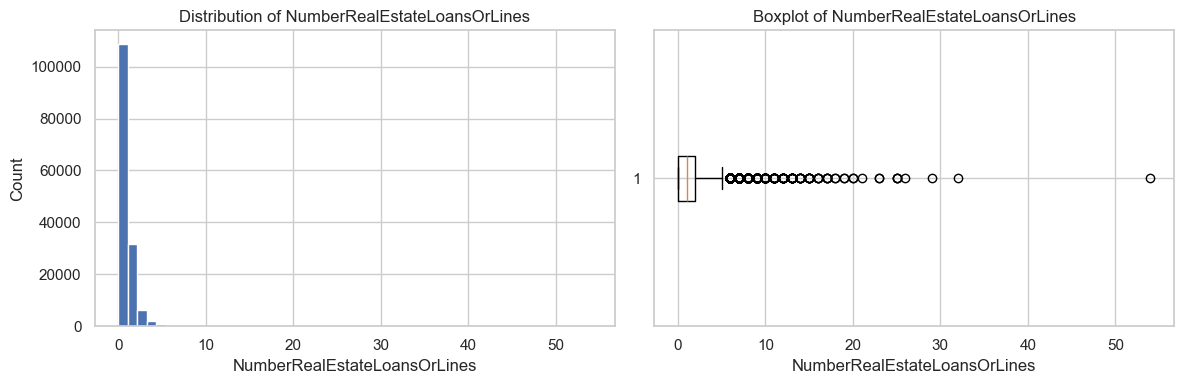

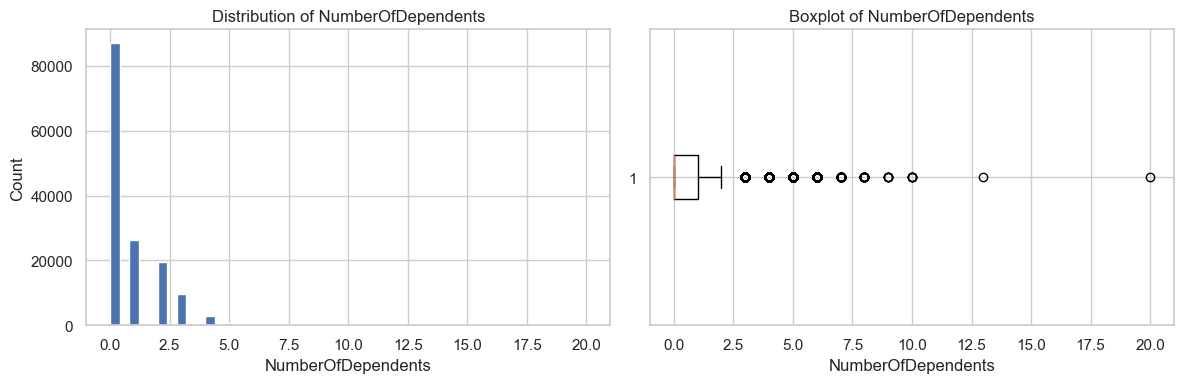

In [23]:
# plotting histograms and boxplots for continuous features
for col in continuous_cols:
    fig, axes = plt.subplots(1,2,figsize=(12,4))
    axes[0].hist(new_df[col].dropna().values,bins=50)
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")
    axes[1].boxplot(new_df[col].dropna().values,vert=False)
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_xlabel(col)
    plt.tight_layout()
    plt.show()

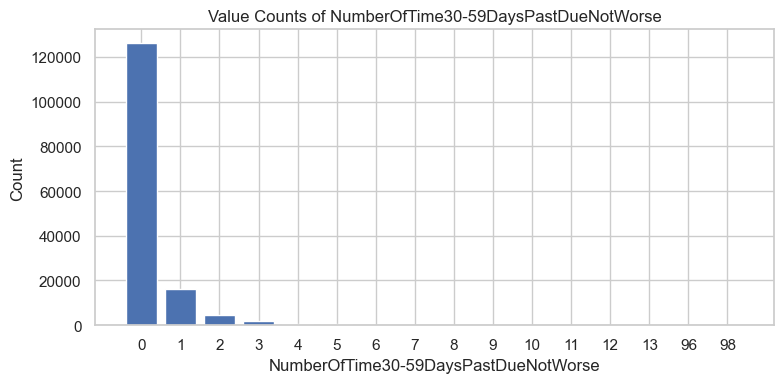

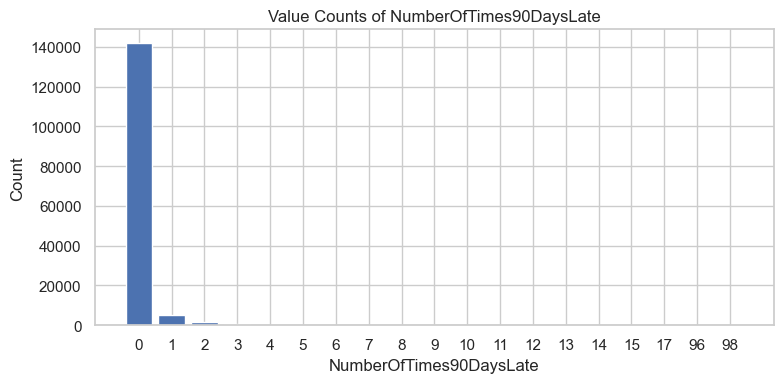

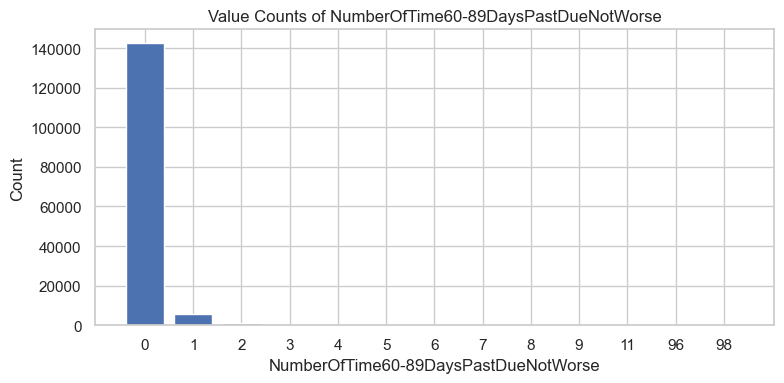

In [24]:
# plotting Countplots for delinquency features
for col in delinquency_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    vc = new_df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str),vc.values)
    ax.set_title(f"Value Counts of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [25]:
special_values = [96, 98]
for col in delinquency_cols:
    print(f"\nSpecial value counts for {col}:")
    display(new_df[col].value_counts().loc[lambda x:x.index.isin(special_values)].to_frame("Count"))


Special value counts for NumberOfTime30-59DaysPastDueNotWorse:


,Count
NumberOfTime30-59DaysPastDueNotWorse,
98,264
96,5



Special value counts for NumberOfTimes90DaysLate:


,Count
NumberOfTimes90DaysLate,
98,264
96,5



Special value counts for NumberOfTime60-89DaysPastDueNotWorse:


,Count
NumberOfTime60-89DaysPastDueNotWorse,
98,264
96,5


The values 96 and 98 in delinquency features are treated as special values because they are unusually large and may represent coded or anomalous records rather than true delinquency counts. Therefore, they are analyzed separately before deciding whether to cap, recode, or remove them.

In [26]:
#unusual value checks
print("Minimum age in dataset:",new_df["age"].min())
print("Count of age = 0 in dataset:",(new_df["age"]==0).sum())
print("Rows with age = 0 in data:")
display(new_df[new_df["age"]==0])

Minimum age in dataset: 0
Count of age = 0 in dataset: 1
Rows with age = 0 in data:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


So, we have an unusual age value (0) in dataset at row no 65695

<br>
<h3><b>FEATURE VS TARGET ANALYSIS</b></h3>

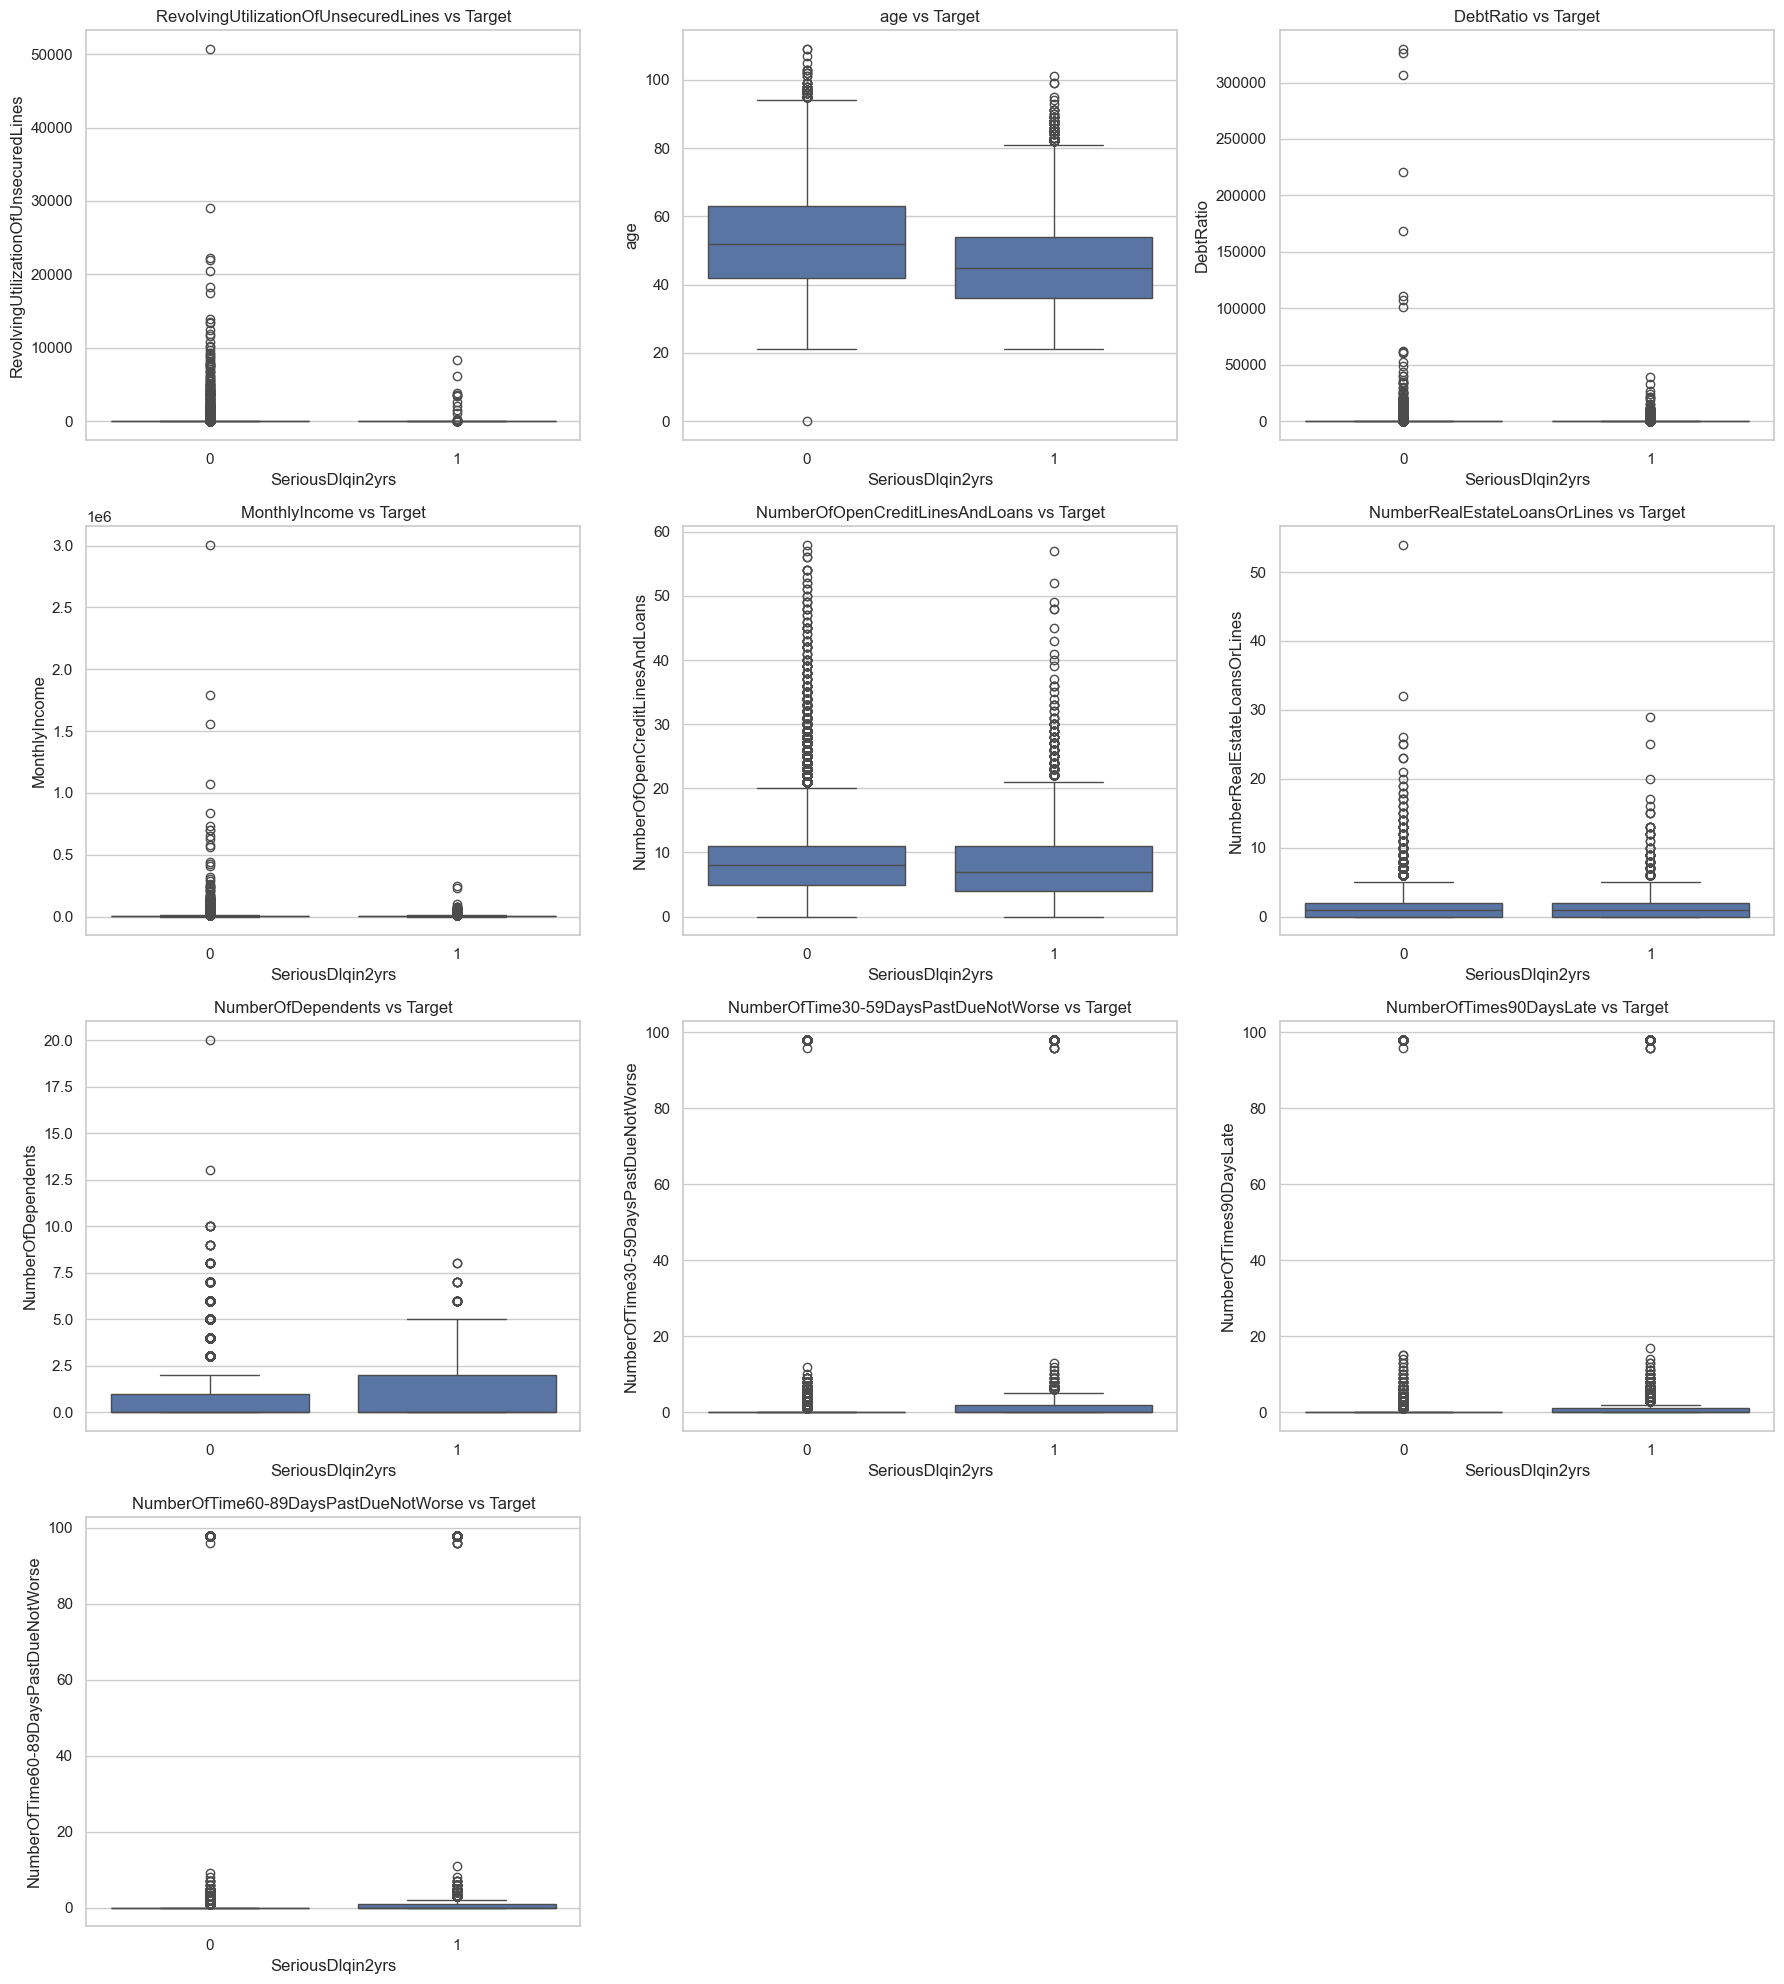

In [27]:
#numerical features vs target
plt.figure(figsize=(18,20))
for i,col in enumerate(continuous_cols+delinquency_cols,1):
    plt.subplot(4,3,i)
    sns.boxplot(x="SeriousDlqin2yrs", y=col, data=new_df)
    plt.title(f"{col} vs Target")
    plt.xlabel("SeriousDlqin2yrs")
plt.tight_layout()
plt.show()

In [28]:
#printing mean values by target
display(new_df.groupby("SeriousDlqin2yrs")[continuous_cols+delinquency_cols].mean().T)

SeriousDlqin2yrs,0,1
RevolvingUtilizationOfUnsecuredLines,6.168855,4.367282
age,52.751375,45.926591
DebtRatio,357.151168,295.121066
MonthlyIncome,6747.837774,5630.826493
NumberOfOpenCreditLinesAndLoans,8.493620,7.882306
NumberRealEstateLoansOrLines,1.020368,0.988530
NumberOfDependents,0.743417,0.948208
NumberOfTime30-59DaysPastDueNotWorse,0.280109,2.388490
NumberOfTimes90DaysLate,0.135225,2.091362
NumberOfTime60-89DaysPastDueNotWorse,0.126666,1.828047


In [29]:
#printing median values by target
display(new_df.groupby("SeriousDlqin2yrs")[continuous_cols+delinquency_cols].median().T)

SeriousDlqin2yrs,0,1
RevolvingUtilizationOfUnsecuredLines,0.133288,0.838853
age,52.000000,45.000000
DebtRatio,0.362659,0.428227
MonthlyIncome,5466.000000,4500.000000
NumberOfOpenCreditLinesAndLoans,8.000000,7.000000
NumberRealEstateLoansOrLines,1.000000,1.000000
NumberOfDependents,0.000000,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0.000000,0.000000
NumberOfTimes90DaysLate,0.000000,0.000000
NumberOfTime60-89DaysPastDueNotWorse,0.000000,0.000000


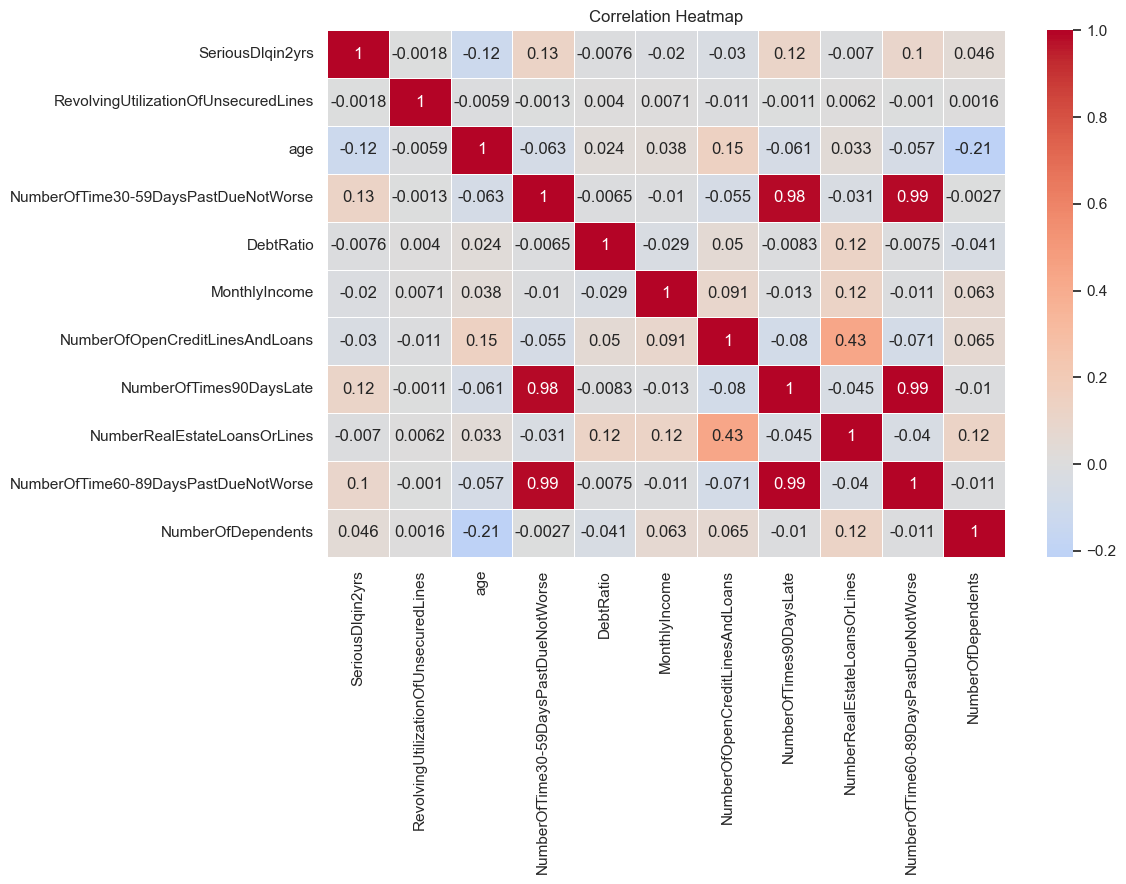

In [30]:
#correlation heatmap for training Data
corr = new_df.corr(numeric_only=True)
plt.figure(figsize=(12,9))
sns.heatmap(corr,cmap="coolwarm",center=0,annot=True,linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [31]:
def iqr_outlier_summary(df, columns):
    rows = []
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3-q1
        lower = q1-1.5*iqr
        upper = q3+1.5*iqr
        outliers = df[(df[col]<lower) | (df[col]>upper)]
        rows.append({
            "Feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Outlier_Count": len(outliers),
            "Outlier_Percent": round(len(outliers) / len(df) * 100, 2)
        })
    return pd.DataFrame(rows)

In [32]:
outlier_summary = iqr_outlier_summary(new_df, continuous_cols+delinquency_cols)
print("Outlier summary using IQR on data:")
display(outlier_summary)

Outlier summary using IQR on data:


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
0,RevolvingUtilizationOfUnsecuredLines,0.029867,0.559046,0.529179,-0.763901,1.352814,763,0.51
1,age,41.000000,63.000000,22.000000,8.000000,96.000000,46,0.03
2,DebtRatio,0.175074,0.868254,0.693180,-0.864696,1.908024,31311,20.87
3,MonthlyIncome,3400.000000,8249.000000,4849.000000,-3873.500000,15522.500000,4879,3.25
4,NumberOfOpenCreditLinesAndLoans,5.000000,11.000000,6.000000,-4.000000,20.000000,3980,2.65
5,NumberRealEstateLoansOrLines,0.000000,2.000000,2.000000,-3.000000,5.000000,793,0.53
6,NumberOfDependents,0.000000,1.000000,1.000000,-1.500000,2.500000,13336,8.89
7,NumberOfTime30-59DaysPastDueNotWorse,0.000000,0.000000,0.000000,0.000000,0.000000,23982,15.99
8,NumberOfTimes90DaysLate,0.000000,0.000000,0.000000,0.000000,0.000000,8338,5.56
9,NumberOfTime60-89DaysPastDueNotWorse,0.000000,0.000000,0.000000,0.000000,0.000000,7604,5.07


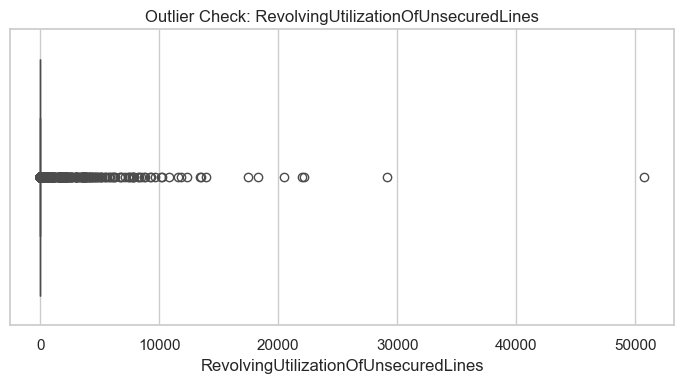

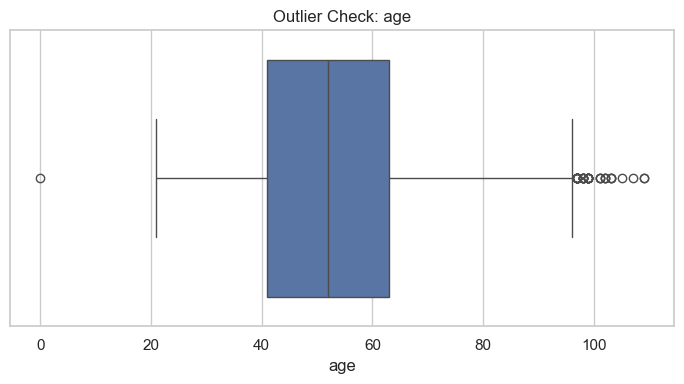

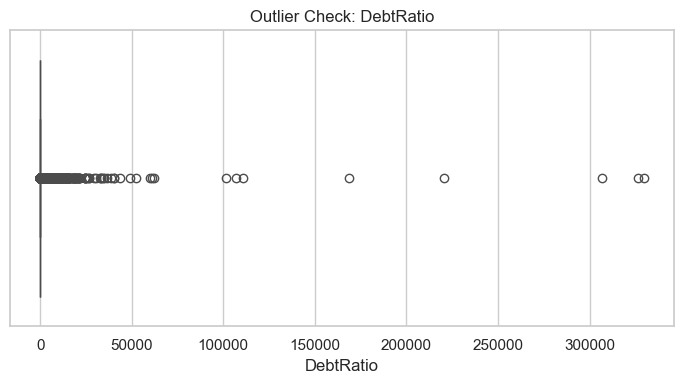

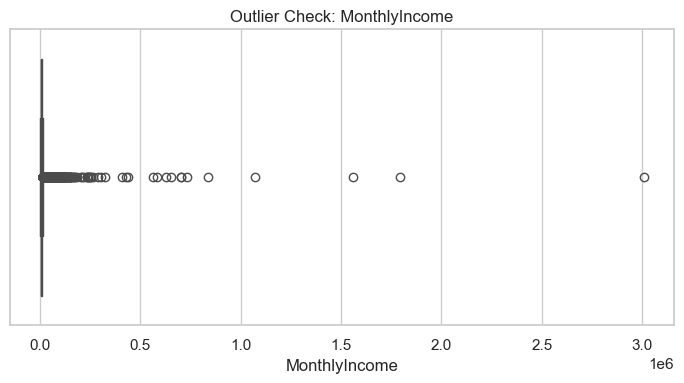

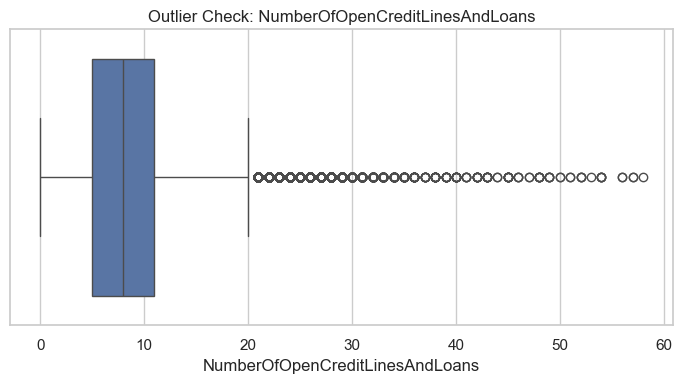

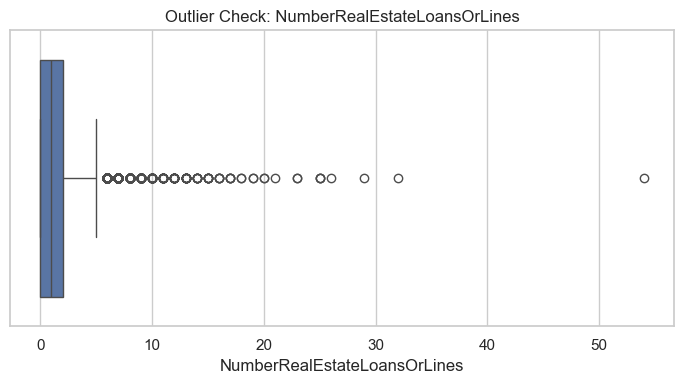

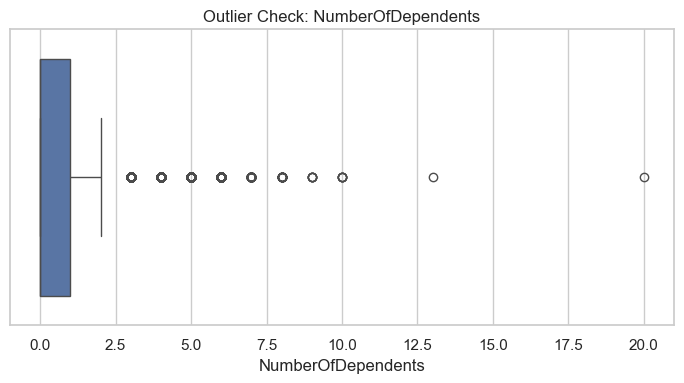

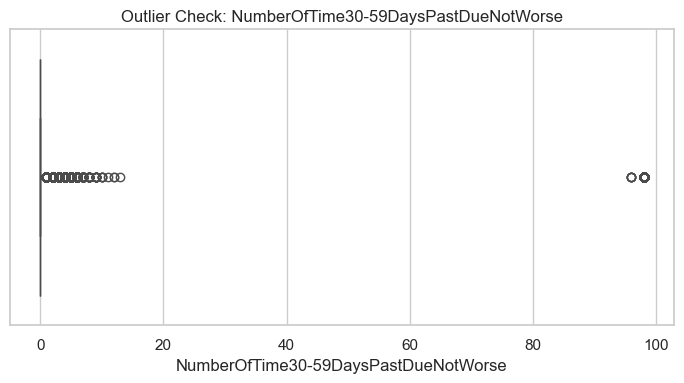

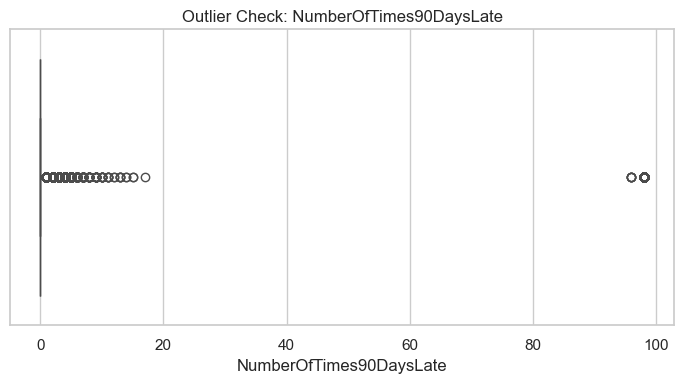

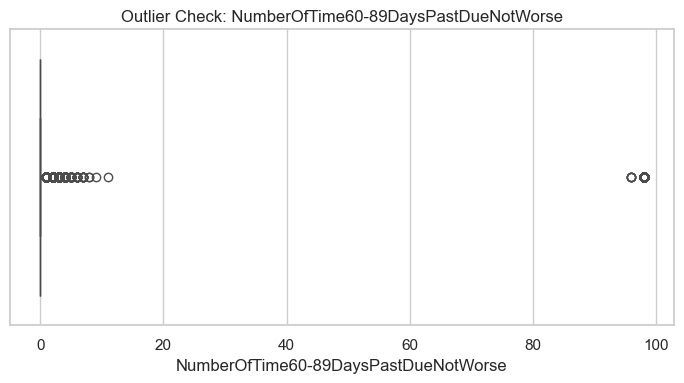

In [33]:
for col in continuous_cols+delinquency_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=new_df[col])
    plt.title(f"Outlier Check: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

<br>
<h1><center><b>DATA PREPROCESSING</b></center></h1>

<br>
<h3><b>Removing Duplicates</b></h3>

In [34]:
# After removing the unnamed column, the dataset contained 609 duplicates. Duplicates can bias the models, so I removed them.
print("Shape before removing duplicates: ", new_df.shape)
print("Duplicate rows before removal:",new_df.duplicated().sum())
new_df = new_df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", new_df.shape) 

Shape before removing duplicates:  (150000, 11)
Duplicate rows before removal: 609
Shape after removing duplicates: (149391, 11)


<h3><b>Handling invalid age</b></h3>

In [35]:
# removing invalid age row with age = 0
new_df = new_df[new_df["age"] > 0].copy().reset_index(drop=True)
print("Shape after removing invalid age row:", new_df.shape)

Shape after removing invalid age row: (149390, 11)


<h3><b>Fixing special values in delinquency columns</b></h3>

In [36]:
#fixing special values (96 and 98) in delinquency columns by recoding them to 0
for col in delinquency_cols:
    new_df[col] = new_df[col].replace({96:0, 98:0})
    print(f"Special value counts for {col} after fixing:")
    print("96:", (new_df[col] == 96).sum())
    print("98:", (new_df[col] == 98).sum())

Special value counts for NumberOfTime30-59DaysPastDueNotWorse after fixing:
96: 0
98: 0
Special value counts for NumberOfTimes90DaysLate after fixing:
96: 0
98: 0
Special value counts for NumberOfTime60-89DaysPastDueNotWorse after fixing:
96: 0
98: 0


<h3><b>Separate features and target</b></h3>

In [37]:
target = "SeriousDlqin2yrs"
X = new_df.drop(columns=[target])
y = new_df[target]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (149390, 10)
Target shape: (149390,)


<br>
<h3><b>Train-test split</b></h3>

We will use a stratified split as our target is higly imbalanced.

In [38]:
# performing a 80-20 train test stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y,)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (119512, 10)
Testing set shape: (29878, 10)


In [39]:
# checking target distribution in train and test
print("Training target distribution:")
display(y_train.value_counts().to_frame("Count"))
print("\nTesting target distribution:")
display(y_test.value_counts().to_frame("Count"))

Training target distribution:


,Count
SeriousDlqin2yrs,
0,111505
1,8007



Testing target distribution:


,Count
SeriousDlqin2yrs,
0,27876
1,2002


In [40]:
#checking missing values in train and test
train_missing = X_train.isna().sum().to_frame("Missing-Count")
train_missing["Missing-Percent"] = (train_missing["Missing-Count"] / len(X_train)*100).round(2)
print("Missing values in training data")
display(train_missing[train_missing["Missing-Count"] > 0])

Missing values in training data


,Missing-Count,Missing-Percent
MonthlyIncome,23351,19.54
NumberOfDependents,3087,2.58


In [41]:
print("Missing values in test data")
test_missing = X_test.isna().sum().to_frame("Missing-Count")
test_missing["Missing-Percent"] = (test_missing["Missing-Count"] / len(X_test)*100).round(2)
display(test_missing[test_missing["Missing-Count"] > 0])

Missing values in test data


,Missing-Count,Missing-Percent
MonthlyIncome,5870,19.65
NumberOfDependents,741,2.48


<h3><b>Handling missing values</b></h3>

In [42]:
# dataset contains missing values in two columns. We impute them with medians using simple imputer
impute_cols = ["MonthlyIncome", "NumberOfDependents"]
imputer = SimpleImputer(strategy="median")
X_train[impute_cols] = imputer.fit_transform(X_train[impute_cols])
X_test[impute_cols] = imputer.transform(X_test[impute_cols])

In [43]:
# checking missing values after imputation to verify
print("Missing values in train:")
print(X_train[impute_cols].isna().sum())
print("Missing values in test:")
print(X_test[impute_cols].isna().sum())

Missing values in train:
MonthlyIncome         0
NumberOfDependents    0
dtype: int64
Missing values in test:
MonthlyIncome         0
NumberOfDependents    0
dtype: int64


In [44]:
print("Skewness in training data:")
display(X_train[continuous_cols + delinquency_cols].skew().to_frame("Skewness"))

Skewness in training data:


,Skewness
RevolvingUtilizationOfUnsecuredLines,105.268499
age,0.193176
DebtRatio,93.069977
MonthlyIncome,128.074458
NumberOfOpenCreditLinesAndLoans,1.250617
NumberRealEstateLoansOrLines,3.647556
NumberOfDependents,1.588058
NumberOfTime30-59DaysPastDueNotWorse,4.287210
NumberOfTimes90DaysLate,9.569141
NumberOfTime60-89DaysPastDueNotWorse,7.450720


RevolvingUtilizationOfUnsecuredLines, DebtRatio and MonthlyIncome are heavily skewed

In [45]:
#capping extreme values
for col in ["RevolvingUtilizationOfUnsecuredLines", "DebtRatio", "MonthlyIncome"]:
    upper_limit = X_train[col].quantile(0.99)
    print(f"{col} upper cap (99th percentile):", upper_limit)
    X_train[col] = X_train[col].clip(upper=upper_limit)
    X_test[col] = X_test[col].clip(upper=upper_limit)

RevolvingUtilizationOfUnsecuredLines upper cap (99th percentile): 1.09078799813
DebtRatio upper cap (99th percentile): 4936.0
MonthlyIncome upper cap (99th percentile): 23333.0


In [46]:
display(X_train[continuous_cols + delinquency_cols].skew().to_frame("Skewness"))

,Skewness
RevolvingUtilizationOfUnsecuredLines,0.909589
age,0.193176
DebtRatio,3.332809
MonthlyIncome,1.776744
NumberOfOpenCreditLinesAndLoans,1.250617
NumberRealEstateLoansOrLines,3.647556
NumberOfDependents,1.588058
NumberOfTime30-59DaysPastDueNotWorse,4.287210
NumberOfTimes90DaysLate,9.569141
NumberOfTime60-89DaysPastDueNotWorse,7.450720


<br>
<h3><b>Feature Scaling</b></h3>

In [47]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)
print("Scaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)
display(X_train_scaled.head())

Scaled X_train shape: (119512, 10)
Scaled X_test shape: (29878, 10)


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
17824,-0.636988,0.184718,-0.352532,-0.349071,0.348608,0.101424,-0.184822,1.749644,-0.196907,-0.667847
73199,-0.897412,0.116884,-0.352532,-0.349873,0.610699,3.014933,-0.184822,-0.017709,-0.196907,-0.667847
66756,0.296540,0.184718,-0.352532,-0.349867,1.850712,1.461061,-0.184822,-0.017709,-0.196907,0.235097
49498,1.938590,0.388219,-0.352532,-0.350136,-1.233522,-1.452448,-0.184822,-0.901385,-0.196907,-0.667847
23061,-0.598660,-0.832788,-0.352532,-0.349998,0.369327,-0.092810,-0.184822,-0.901385,-0.196907,-0.667847


In [48]:
#checking class imbalance again in the training split
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print("Negative class count:", neg)
print("Positive class count:", pos)
print("scale_pos_weight:", round(scale_pos_weight, 4))

Negative class count: 111505
Positive class count: 8007
scale_pos_weight: 13.9259


<br>
<h3><b>Models Selection</b></h3>

In [49]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth = 8, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boost": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss",
    ),
}
sample_weight_gb = np.where(y_train == 1, scale_pos_weight, 1.0)

<br>
<h1><center><b>MODEL TRAINING AND EVALUATION</b></center></h1>

In [50]:
# fit models
for name, model in models.items():
    if name == "Gradient Boost":
        model.fit(X_train_scaled, y_train, sample_weight=sample_weight_gb)
    else:
        model.fit(X_train_scaled, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boost trained successfully.
XGBoost trained successfully.


In [51]:
# model evaluation on train and test sets
results = []
predictions = {}
for name, model in models.items():
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    # probability scores for ROC AUC
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_test_proba)
    results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": auc
    })
    predictions[name] = {
        "y_train_pred": y_train_pred,
        "y_test_pred": y_test_pred,
        "y_test_proba": y_test_proba
    }
results_df = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
display(results_df)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.825658,0.815449,0.228089,0.735764,0.348227,0.857938
1,Logistic Regression,0.797920,0.798614,0.214803,0.755245,0.334476,0.857518
2,XGBoost,0.801133,0.795334,0.215048,0.775225,0.336696,0.864612
3,Gradient Boost,0.787645,0.785695,0.210117,0.796703,0.332534,0.865475
4,Decision Tree,0.787946,0.781445,0.202262,0.768232,0.320217,0.837445


<br>
<h3><b>Visualizing training and test accuracy </b></h3>

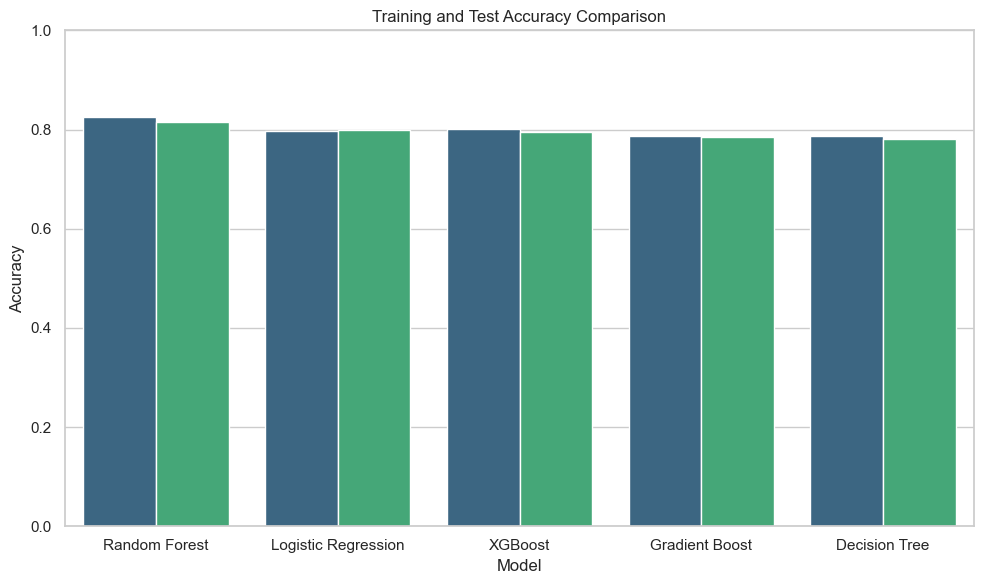

In [52]:
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=["Train Accuracy", "Test Accuracy"],
    var_name="Dataset",
    value_name="Accuracy"
)
plt.figure(figsize=(10, 6))
sns.barplot(data=results_melted, x="Model", y="Accuracy", palette = 'viridis', hue="Dataset", legend = False)
plt.title("Training and Test Accuracy Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

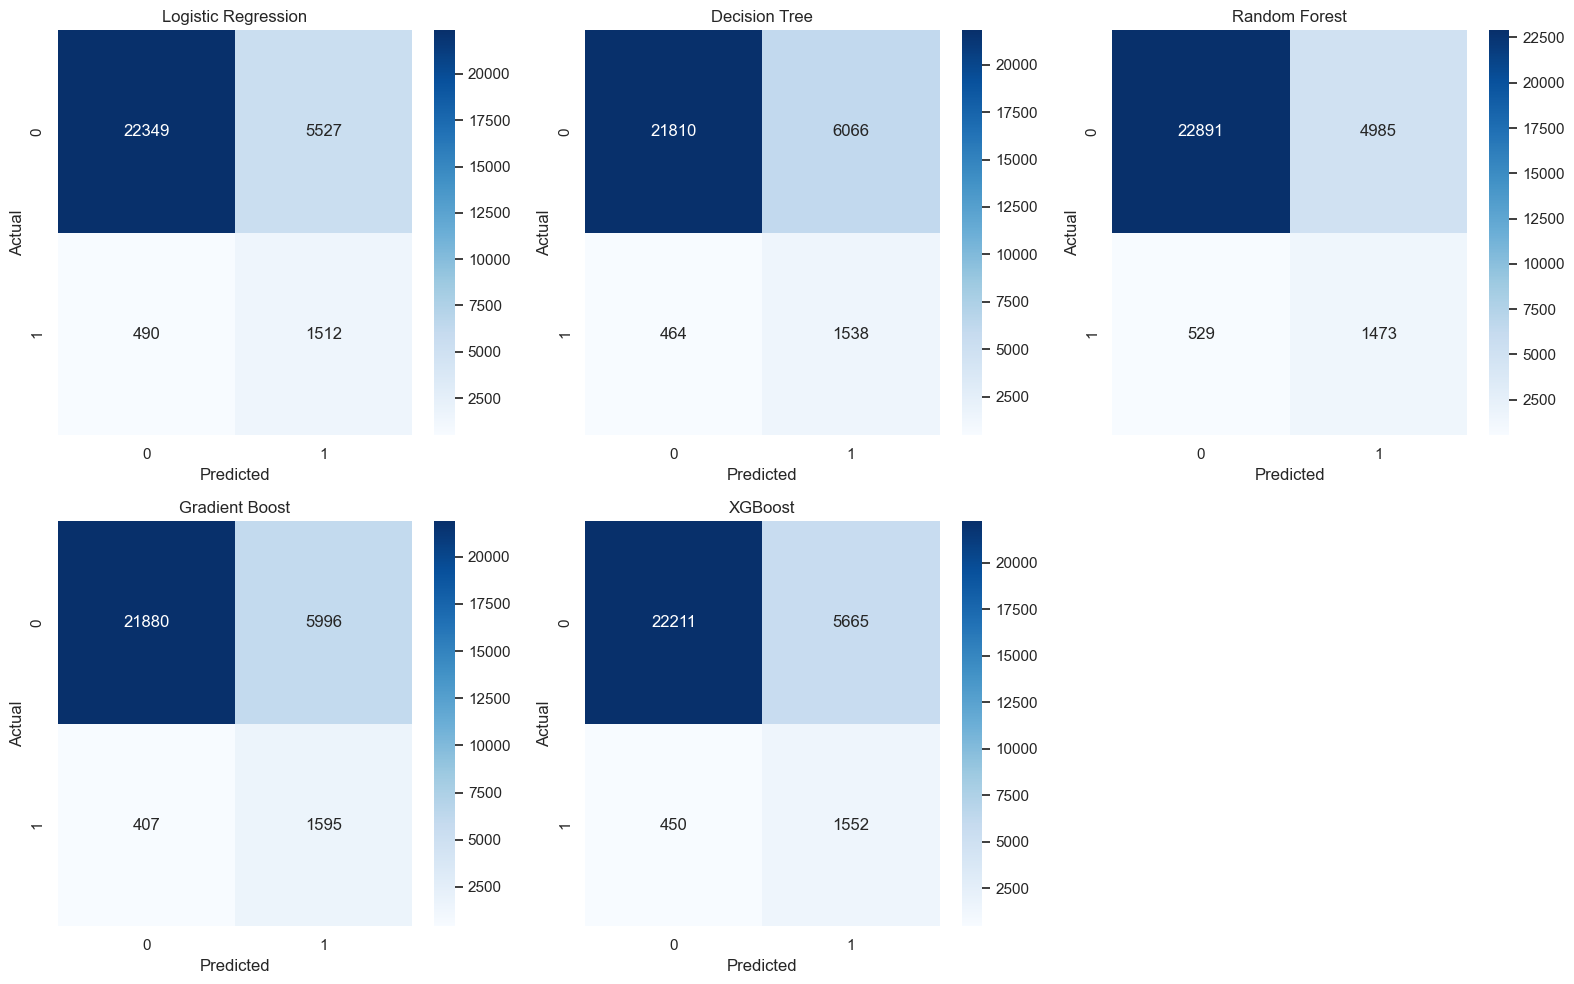

In [53]:
fig, axes = plt.subplots(2,3,figsize=(16,10))
axes = axes.flatten()
for idx,(name,model) in enumerate(models.items()):
    cm = confusion_matrix(y_test,predictions[name]["y_test_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx])
    axes[idx].set_title(name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

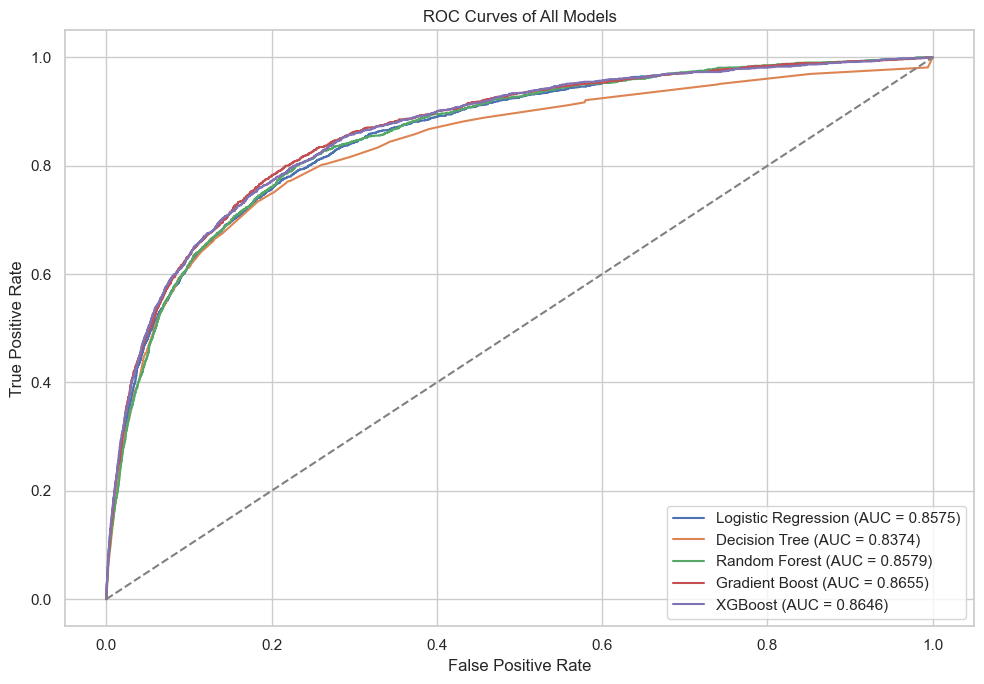

In [54]:
# plotting ROC curves matrices for models performance
plt.figure(figsize=(10, 7))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, predictions[name]["y_test_proba"])
    auc_score = roc_auc_score(y_test, predictions[name]["y_test_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curves of All Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

So, gradient boosting has the best ROC-AUC Score

In [55]:
# classification report for each model
for name in models:
    print("="*60)
    print(name)
    print(classification_report(y_test, predictions[name]["y_test_pred"], zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     27876
           1       0.21      0.76      0.33      2002

    accuracy                           0.80     29878
   macro avg       0.60      0.78      0.61     29878
weighted avg       0.93      0.80      0.84     29878

Decision Tree
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     27876
           1       0.20      0.77      0.32      2002

    accuracy                           0.78     29878
   macro avg       0.59      0.78      0.60     29878
weighted avg       0.93      0.78      0.83     29878

Random Forest
              precision    recall  f1-score   support

           0       0.98      0.82      0.89     27876
           1       0.23      0.74      0.35      2002

    accuracy                           0.82     29878
   macro avg       0.60      0.78      0.62     29878
weighted avg       0.93   

<br>
<h1><center><b>MODEL OPTIMIZATION</b></center></h1>

<br>
<h3><b>Hyperparameter tuning</b></h3>

In [56]:
# defining the parameter grids for all selected models
param_grids = {
    "Logistic Regression": {
        "C": [0.1, 1, 10],
        "solver": ["liblinear", "lbfgs"]
    },
    "Decision Tree": {
        "max_depth": [3, 5, 7],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "criterion": ["gini", "entropy"]
    },
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [5, 8],
        "min_samples_leaf": [20, 50],
        "max_features": ["sqrt"]
    },
    "Gradient Boost": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.05],
        "max_depth": [3, 4],
        "subsample": [0.8, 0.9],
    },
    "XGBoost": {
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "learning_rate": [0.01, 0.05],
        "subsample": [0.7, 0.8],
        "colsample_bytree": [0.8, 0.9],
        "min_child_weight": [5, 10],
        "reg_lambda": [1, 10] 
    }
}

In [57]:
# setting up the cross-validation 3 folds
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# tuning the models with GridSearchCV
best_models = {}
grid_results = []
for name, model in models.items():
    print("=" * 80)
    print(f"Tuning {name}...")
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        verbose=0
    )
    if name == "Gradient Boost":
        grid.fit(X_train_scaled, y_train, sample_weight=sample_weight_gb)
    else:
        grid.fit(X_train_scaled, y_train)
    best_models[name] = grid.best_estimator_
    grid_results.append({
        "Model": name,
        "Best CV ROC AUC": grid.best_score_,
        "Best Parameters": grid.best_params_
    })
    print("Best CV ROC AUC:", round(grid.best_score_, 4))
    print("Best Parameters:", grid.best_params_)

Tuning Logistic Regression...
Best CV ROC AUC: 0.854
Best Parameters: {'C': 0.1, 'solver': 'liblinear'}
Tuning Decision Tree...
Best CV ROC AUC: 0.8411
Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Tuning Random Forest...
Best CV ROC AUC: 0.8612
Best Parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 50, 'n_estimators': 200}
Tuning Gradient Boost...
Best CV ROC AUC: 0.8638
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.9}
Tuning XGBoost...
Best CV ROC AUC: 0.8641
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 200, 'reg_lambda': 10, 'subsample': 0.8}


In [58]:
grid_results_df = pd.DataFrame(grid_results).sort_values(by="Best CV ROC AUC", ascending=False).reset_index(drop=True)
display(grid_results_df)

,Model,Best CV ROC AUC,Best Parameters
0,XGBoost,0.864118,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
1,Gradient Boost,0.863826,"{'learning_rate': 0.05, 'max_depth': 4, 'n_est..."
2,Random Forest,0.861212,"{'max_depth': 8, 'max_features': 'sqrt', 'min_..."
3,Logistic Regression,0.854033,"{'C': 0.1, 'solver': 'liblinear'}"
4,Decision Tree,0.841089,"{'criterion': 'entropy', 'max_depth': 5, 'min_..."


In [59]:
# evaluate tuned models
tuned_results = []
tuned_predictions = {}
for name, model in best_models.items():
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_test_proba)
    tuned_results.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": auc
    })
    tuned_predictions[name] = {
        "y_train_pred": y_train_pred,
        "y_test_pred": y_test_pred,
        "y_test_proba": y_test_proba
    }
tuned_results_df = pd.DataFrame(tuned_results).sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)
display(tuned_results_df)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.797870,0.798581,0.214773,0.755245,0.334439,0.857515
1,XGBoost,0.799652,0.794364,0.215756,0.785215,0.338501,0.866033
2,Random Forest,0.793251,0.790180,0.212892,0.790210,0.335418,0.862390
3,Gradient Boost,0.795184,0.790180,0.212583,0.788212,0.334854,0.864857
4,Decision Tree,0.724237,0.721066,0.170483,0.818182,0.282171,0.842842


<br>
<h3><b>Before and After Optimization Comparison</b></h3>

In [62]:
comparison_df = results_df.merge(
    tuned_results_df,
    on="Model",
    suffixes=(" Before Tuning", " After Tuning")
)
display(comparison_df)

,Model,Train Accuracy Before Tuning,Test Accuracy Before Tuning,Precision Before Tuning,Recall Before Tuning,F1 Score Before Tuning,ROC AUC Before Tuning,Train Accuracy After Tuning,Test Accuracy After Tuning,Precision After Tuning,Recall After Tuning,F1 Score After Tuning,ROC AUC After Tuning
0,Random Forest,0.825658,0.815449,0.228089,0.735764,0.348227,0.857938,0.793251,0.790180,0.212892,0.790210,0.335418,0.862390
1,Logistic Regression,0.797920,0.798614,0.214803,0.755245,0.334476,0.857518,0.797870,0.798581,0.214773,0.755245,0.334439,0.857515
2,XGBoost,0.801133,0.795334,0.215048,0.775225,0.336696,0.864612,0.799652,0.794364,0.215756,0.785215,0.338501,0.866033
3,Gradient Boost,0.787645,0.785695,0.210117,0.796703,0.332534,0.865475,0.795184,0.790180,0.212583,0.788212,0.334854,0.864857
4,Decision Tree,0.787946,0.781445,0.202262,0.768232,0.320217,0.837445,0.724237,0.721066,0.170483,0.818182,0.282171,0.842842


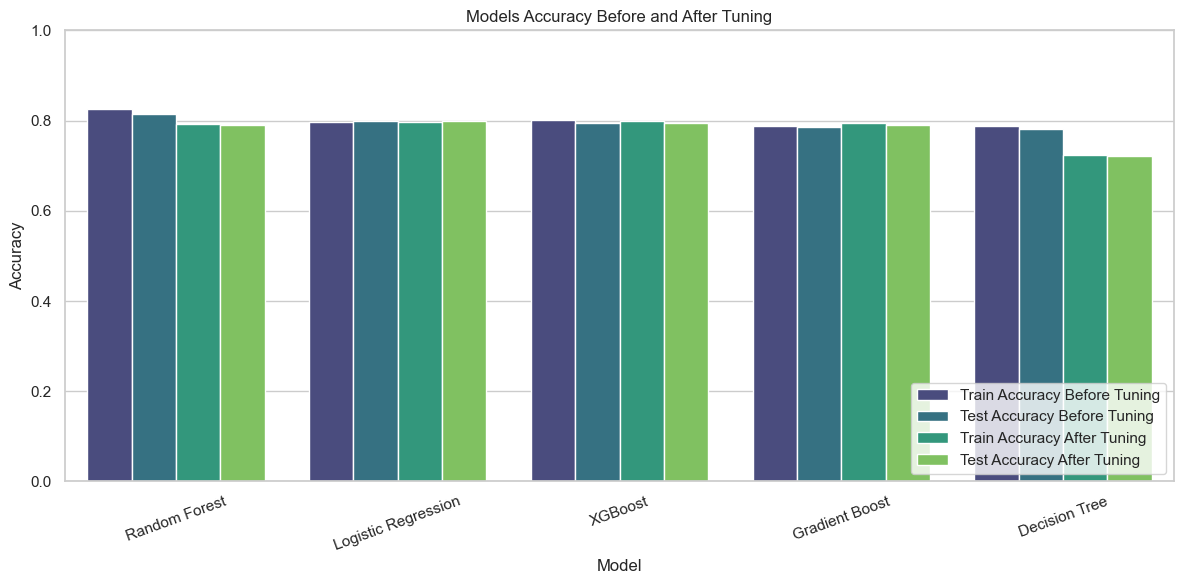

In [66]:
compare_melted = comparison_df.melt(
    id_vars="Model",
    value_vars=[
        "Train Accuracy Before Tuning", 
        "Test Accuracy Before Tuning", 
        "Train Accuracy After Tuning", 
        "Test Accuracy After Tuning"
    ],
    var_name="Metric",
    value_name="Accuracy"
)
plt.figure(figsize=(12, 6))
sns.barplot(data=compare_melted, x="Model", y="Accuracy", palette="viridis", hue="Metric")
plt.title("Models Accuracy Before and After Tuning")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

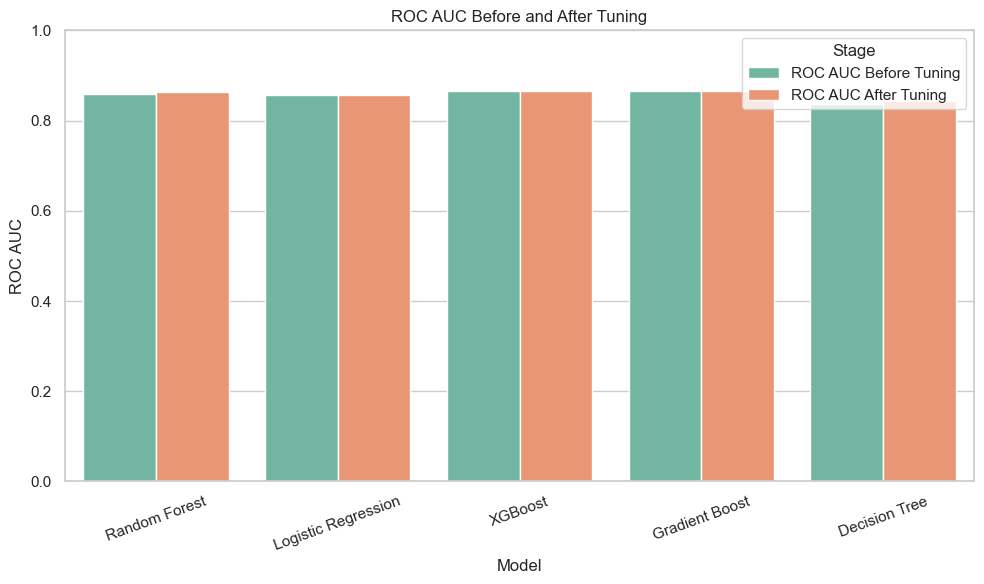

In [68]:
auc_compare = comparison_df[[
    "Model",
    "ROC AUC Before Tuning",
    "ROC AUC After Tuning"
]].melt(
    id_vars="Model",
    var_name="Stage",
    value_name="ROC AUC"
)
plt.figure(figsize=(10, 6))
sns.barplot(data=auc_compare, x="Model", y="ROC AUC", hue="Stage", palette="Set2")
plt.title("ROC AUC Before and After Tuning")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

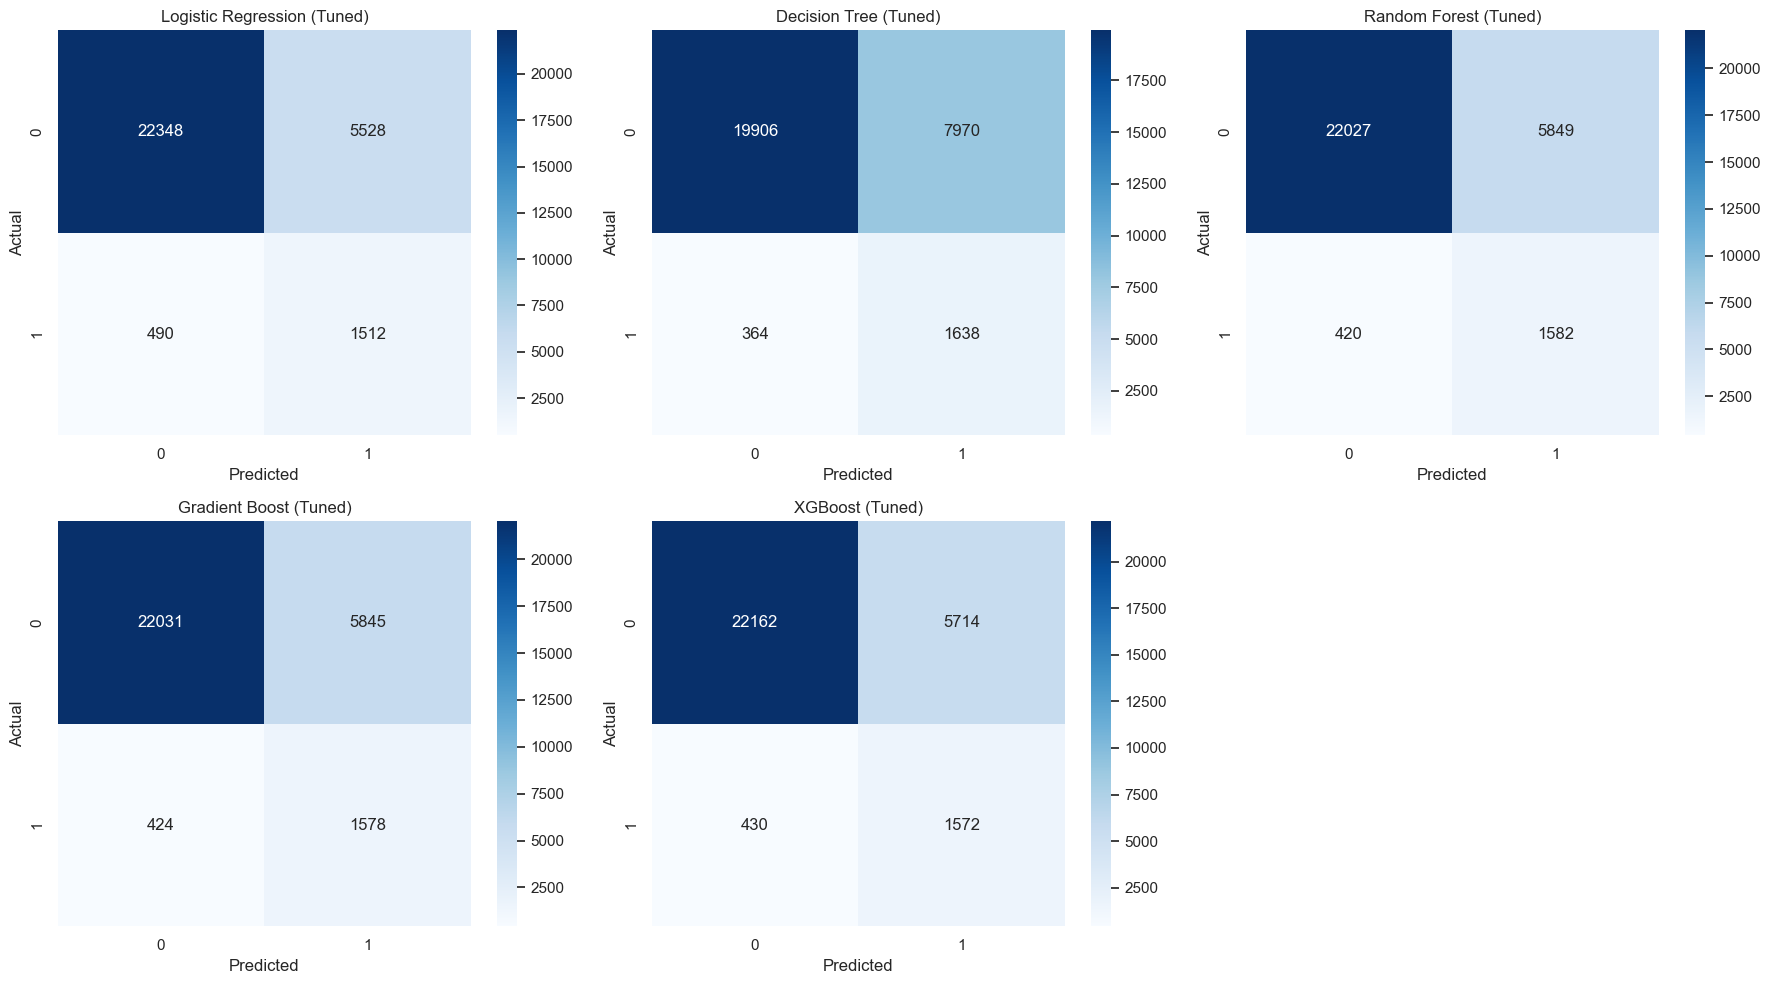

In [70]:
#plotting confusion matrices for tuned models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, name in enumerate(best_models.keys()):
    cm = confusion_matrix(y_test, tuned_predictions[name]["y_test_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx])
    axes[idx].set_title(f"{name} (Tuned)")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

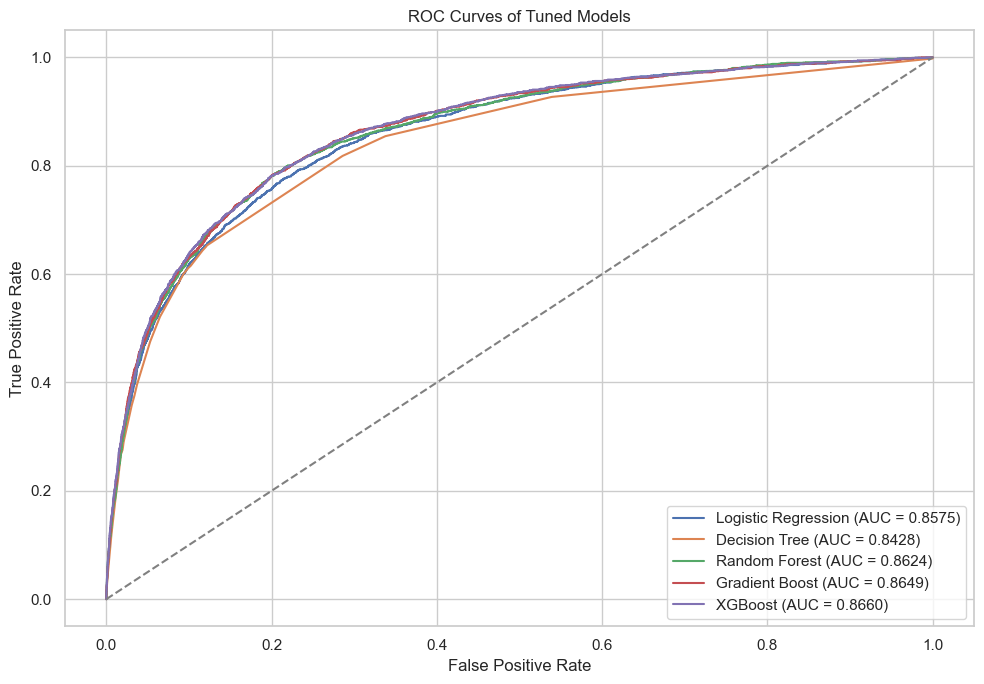

In [72]:
# roc curves for tuned models
plt.figure(figsize=(10, 7))
for name in best_models.keys():
    fpr, tpr, _ = roc_curve(y_test, tuned_predictions[name]["y_test_proba"])
    auc_score = roc_auc_score(y_test, tuned_predictions[name]["y_test_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curves of Tuned Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
# final performance summary
final_summary = tuned_results_df.copy()
# sort by ROC AUC first and then by F1 Score
final_summary = final_summary.sort_values(
    by=["ROC AUC", "F1 Score"],
    ascending=[False, False]
).reset_index(drop=True)
display(final_summary)
print("Best tuned model based on ROC AUC and F1 Score:")
print(final_summary.iloc[0]["Model"])
print("ROC AUC:", final_summary.iloc[0]["ROC AUC"])
print("F1 Score:", final_summary.iloc[0]["F1 Score"])

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC AUC
0,XGBoost,0.799652,0.794364,0.215756,0.785215,0.338501,0.866033
1,Gradient Boost,0.795184,0.790180,0.212583,0.788212,0.334854,0.864857
2,Random Forest,0.793251,0.790180,0.212892,0.790210,0.335418,0.862390
3,Logistic Regression,0.797870,0.798581,0.214773,0.755245,0.334439,0.857515
4,Decision Tree,0.724237,0.721066,0.170483,0.818182,0.282171,0.842842


Best tuned model based on ROC AUC and F1 Score:
XGBoost
ROC AUC: 0.8660328317829393
F1 Score: 0.3385012919896641


In [76]:
best_model = best_models["XGBoost"]  
feature_importance = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": best_model.feature_importances_
})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False).reset_index(drop=True)
display(feature_importance)

,Feature,Importance
0,NumberOfTimes90DaysLate,0.273061
1,RevolvingUtilizationOfUnsecuredLines,0.239820
2,NumberOfTime30-59DaysPastDueNotWorse,0.223069
3,NumberOfTime60-89DaysPastDueNotWorse,0.115030
4,NumberRealEstateLoansOrLines,0.040003
5,NumberOfOpenCreditLinesAndLoans,0.031064
6,age,0.029869
7,DebtRatio,0.018359
8,MonthlyIncome,0.015714
9,NumberOfDependents,0.014012


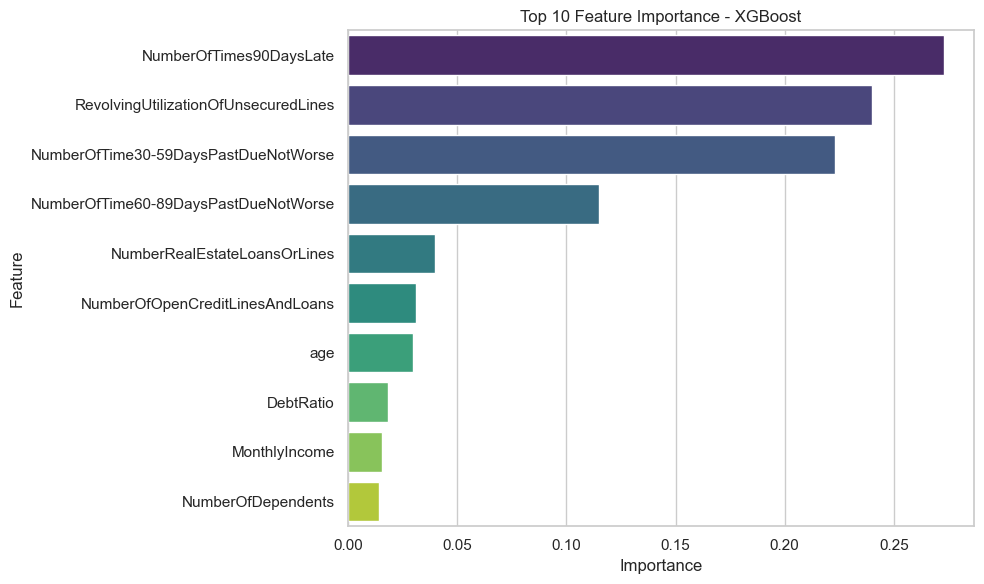

In [78]:
# plot top important features
top_features = feature_importance.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
plt.title("Top 10 Feature Importance - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [80]:
import joblib
# saving the best model
joblib.dump(best_models["XGBoost"], "best_xgboost_model.pkl")
# saving preprocessing objects
joblib.dump(imputer, "imputer.pkl")
joblib.dump(scaler, "scaler.pkl")
# save column order
joblib.dump(X_train.columns.tolist(), "feature_columns.pkl")
# saving cap values
cap_values = {
    "RevolvingUtilizationOfUnsecuredLines": X_train["RevolvingUtilizationOfUnsecuredLines"].quantile(0.99),
    "DebtRatio": X_train["DebtRatio"].quantile(0.99),
    "MonthlyIncome": X_train["MonthlyIncome"].quantile(0.99)
}
joblib.dump(cap_values, "cap_values.pkl")
print("All files saved successfully.")

All files saved successfully.


In [1]:
import platform
print(platform.python_version())

3.13.5
